In [1]:
!pip install visualkeras ann-visualizer -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 993.7/993.7 kB 20.8 MB/s eta 0:00:0000:01


# 1. Environment Setup

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# TensorFlow/Keras Components
import tensorflow as tf
from tensorflow.keras import Sequential, layers, utils, callbacks, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array

# Visualization Utilities
from IPython.display import display
import visualkeras

# Configuration
plt.style.use('ggplot')
np.set_printoptions(precision=3, suppress=True)

# 2. Data Preparation

In [3]:
class DataLoader:
    def __init__(self, data_path, img_size=(64, 64)):
        self.data_path = data_path
        self.img_size = img_size
        self.expected_classes = [chr(c) for c in range(65, 91)] + [str(i) for i in range(1, 10)]
        self.class_map = {i: self.expected_classes[i] for i in range(35)}
        
    def _edge_enhancement(self, img):
        """Preprocessing pipeline for sign images"""
        blurred = cv2.GaussianBlur(img, (5,5), 2)
        thresholded = cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, 11, 2
        )
        _, processed = cv2.threshold(
            thresholded, 70, 255, 
            cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU
        )
        return processed

    def load_dataset(self, test_size=0.2, validation_size=0.2):
        """Load and preprocess the ISL dataset"""
        images, labels = [], []
        
        # Get list of directories (each directory is a class)
        directories = [d for d in os.listdir(self.data_path) 
                       if os.path.isdir(os.path.join(self.data_path, d))]
        
        # Create a mapping from directory names to class indices
        class_mapping = {class_name: idx for idx, class_name in enumerate(self.expected_classes)}
        
        for class_dir in directories:
            # Skip directories that aren't in our expected classes
            if class_dir not in class_mapping:
                print(f"Skipping unexpected directory: {class_dir}")
                continue
                
            class_idx = class_mapping[class_dir]
            class_path = os.path.join(self.data_path, class_dir)
            print(f"Processing class {class_dir} => Index {class_idx} ({class_idx+1}/35)")
            
            for img_file in os.listdir(class_path):
                img_path = os.path.join(class_path, img_file)
                img = cv2.imread(img_path, 0)  # Read as grayscale
                
                # Apply preprocessing
                processed = self._edge_enhancement(img)
                resized = cv2.resize(processed, self.img_size)
                array_img = img_to_array(resized)
                
                images.append(array_img)
                labels.append(class_idx)
                
        # Convert to numpy arrays and normalize
        images = np.array(images, dtype='float32') / 255.0
        labels = utils.to_categorical(labels, num_classes=35)
        
        # First split: train + test
        X_train, X_test, y_train, y_test = train_test_split(
            images, labels, 
            test_size=test_size, 
            stratify=labels,
            random_state=42
        )
        
        # Second split: train + validation
        X_train, X_val, y_train, y_val = train_test_split(
            X_train, y_train, 
            test_size=validation_size, 
            stratify=y_train,
            random_state=42
        )
        
        return X_train, X_val, X_test, y_train, y_val, y_test

# 3. Model Architecture

In [4]:
class CNN_Model:
    @staticmethod
    def build(input_shape=(64, 64, 1), num_classes=35):
        model = Sequential([
            # Feature extraction
            layers.Conv2D(32, (3,3), activation='relu', padding='same', 
                        input_shape=input_shape),
            layers.MaxPool2D((2,2)),
            
            layers.Conv2D(64, (3,3), activation='relu', padding='same'),
            layers.MaxPool2D((2,2)),
            
            layers.Conv2D(128, (3,3), activation='relu', padding='same'),
            layers.MaxPool2D((2,2)),
            
            # Classification
            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation='softmax')
        ])
        
        return model

class LSTM_Model:
    @staticmethod
    def build(input_shape=(64, 64, 1), num_classes=35):
        model = Sequential([
            # CNN for feature extraction
            layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
            layers.MaxPool2D((2, 2)),
            
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.MaxPool2D((2, 2)),
            
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.MaxPool2D((2, 2)),
            
            # Reshape output for LSTM (time steps, features)
            layers.Reshape((-1, 128)),  # Flatten spatial dimensions into time steps
            
            # LSTM for sequence processing
            layers.LSTM(128, return_sequences=True),  # First LSTM layer
            layers.LSTM(64),  # Second LSTM layer
            
            # Fully connected layers for classification
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation='softmax')
        ])
        
        return model

class CNN_ATN_Model:
    @staticmethod
    def build(input_shape=(64, 64, 1), num_classes=35):
        input_layer = layers.Input(shape=input_shape)
    
        # CNN Feature Extraction
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
        x = layers.MaxPool2D((2, 2))(x)
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.MaxPool2D((2, 2))(x)
        
        # Attention Mechanism
        attention = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)
        attention = layers.Reshape((x.shape[1] * x.shape[2],))(attention)
        attention = layers.RepeatVector(x.shape[-1])(attention)
        attention = layers.Reshape(x.shape[1:])(attention)
        x = layers.Multiply()([x, attention])
        
        # Classification
        x = layers.Flatten()(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        output = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(input_layer, output)
        return model

# 4. Training Utilities

In [5]:
class TrainingUtils:
    @staticmethod
    def plot_training_history(history, epochs):
        """Visualize training progress"""
        plt.figure(figsize=(12, 5))
        
        # Loss plot
        plt.subplot(1, 2, 1)
        plt.plot(range(1, epochs+1), history.history['loss'], 'b-o', 
                label='Training Loss')
        plt.plot(range(1, epochs+1), history.history['val_loss'], 'r--s', 
                label='Validation Loss')
        plt.title('Loss Evolution')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        
        # Accuracy plot
        plt.subplot(1, 2, 2)
        plt.plot(range(1, epochs+1), history.history['accuracy'], 'b-o', 
                label='Training Accuracy')
        plt.plot(range(1, epochs+1), history.history['val_accuracy'], 'r--s', 
                label='Validation Accuracy')
        plt.title('Accuracy Progress')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        
        plt.tight_layout()
        plt.show()

    @staticmethod
    def generate_performance_report(model, x_test, y_test, class_map):
        """Generate comprehensive evaluation metrics"""
        y_pred = model.predict(x_test)
        y_true = np.argmax(y_test, axis=1)
        y_pred_classes = np.argmax(y_pred, axis=1)
        
        # Classification report
        print("\nClassification Report:")
        print(metrics.classification_report(
            y_true, y_pred_classes,
            target_names=list(class_map.values())
        ))
        
        # Confusion matrix visualization
        plt.figure(figsize=(20, 15))
        sns.heatmap(
            metrics.confusion_matrix(y_true, y_pred_classes),
            annot=True, fmt='d',
            xticklabels=class_map.values(),
            yticklabels=class_map.values()
        )
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

# Configuration

In [6]:

DATA_PATH = '/kaggle/input/indian-sign-language-isl/Indian'  # Update this path
IMG_SIZE = (128, 128)

In [7]:
# Data loading
loader = DataLoader(DATA_PATH, IMG_SIZE)
x_train, x_val, x_test, y_train, y_val, y_test =loader.load_dataset()


Processing class N => Index 13 (14/35)
Processing class 7 => Index 32 (33/35)
Processing class R => Index 17 (18/35)
Processing class 2 => Index 27 (28/35)
Processing class B => Index 1 (2/35)
Processing class I => Index 8 (9/35)
Processing class F => Index 5 (6/35)
Processing class H => Index 7 (8/35)
Processing class 5 => Index 30 (31/35)
Processing class E => Index 4 (5/35)
Processing class U => Index 20 (21/35)
Processing class M => Index 12 (13/35)
Processing class 8 => Index 33 (34/35)
Processing class X => Index 23 (24/35)
Processing class K => Index 10 (11/35)
Processing class Q => Index 16 (17/35)
Processing class Y => Index 24 (25/35)
Processing class S => Index 18 (19/35)
Processing class G => Index 6 (7/35)
Processing class A => Index 0 (1/35)
Processing class O => Index 14 (15/35)
Processing class T => Index 19 (20/35)
Processing class V => Index 21 (22/35)
Processing class Z => Index 25 (26/35)
Processing class 3 => Index 28 (29/35)
Processing class 1 => Index 26 (27/35)


# CNN Attention Model

In [8]:
MODEL_PATH = 'isl_cnn_atn_v1.h5'
EPOCHS = 50
LR = 1e-5

In [9]:
# Model setup
model = CNN_ATN_Model.build(input_shape=(*IMG_SIZE, 1))
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 32)   │            320 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 32)     │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 64, 64, 64)     │         18,496 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 32, 32, 1)      │             65 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1024)           │              0 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ repeat_vector             │ (None, 64, 1024)       │              0 │ reshape[0][0]          │
│ (RepeatVector)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_1 (Reshape)       │ (None, 32, 32, 64)     │              0 │ repeat_vector[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 32, 32, 64)     │              0 │ max_pooling2d_1[0][0], │
│                           │                        │                │ reshape_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 65536)          │              0 │ multiply[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │      8,388,736 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 128)            │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 35)             │          4,515 │ dropout[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 8,412,132 (32.09 MB)

 Trainable params: 8,412,132 (32.09 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.10/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


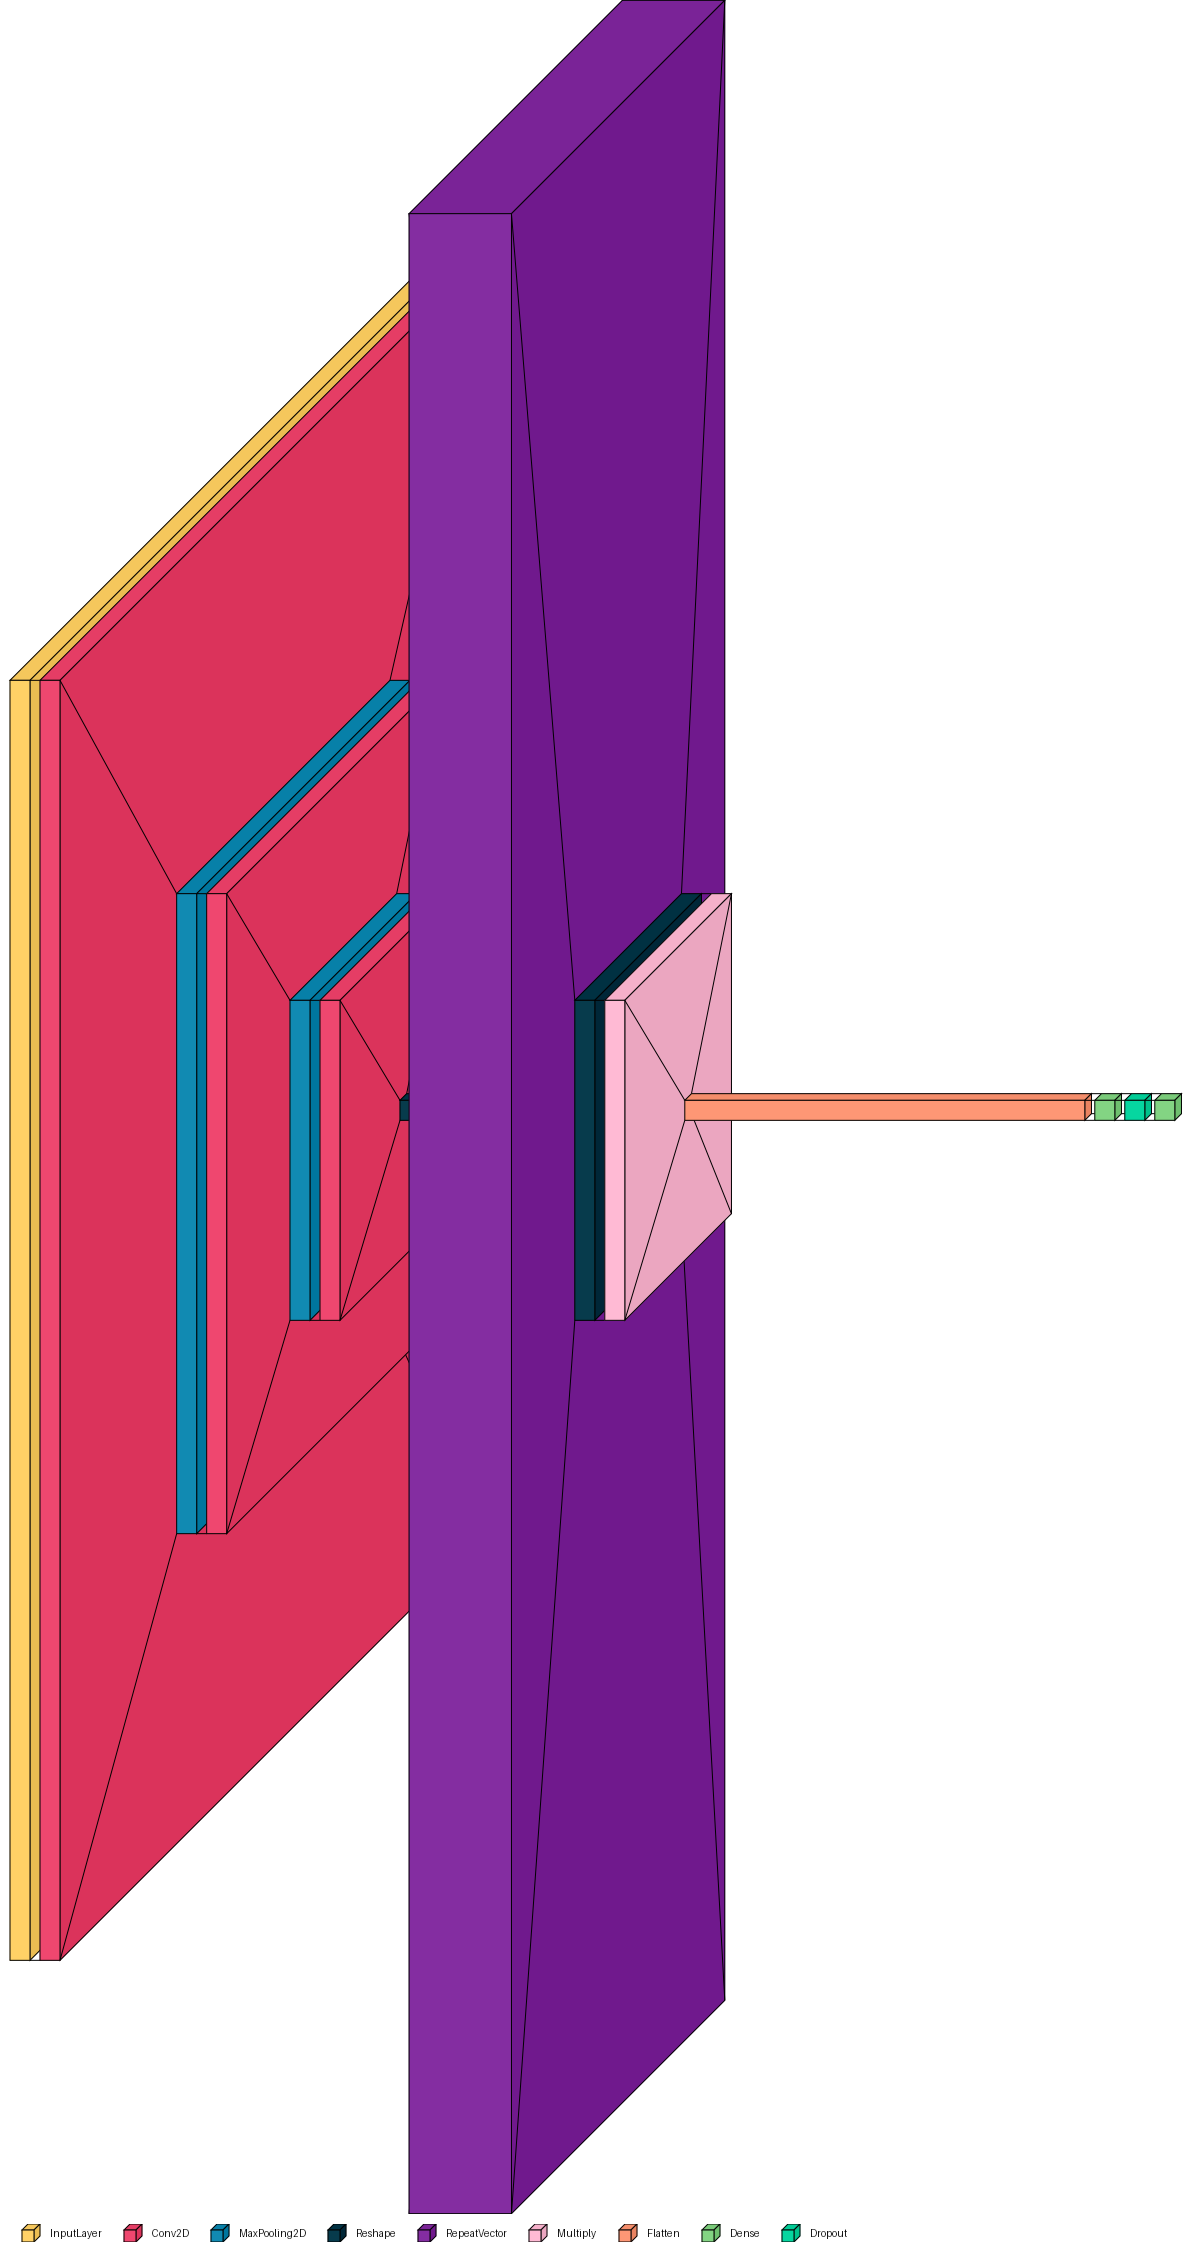

In [10]:
# Model visualization
print("Model Architecture:")
model.summary()
visualkeras.layered_view(model, legend=True, scale_xy=10)

In [11]:
# Training
print("\nStarting Training...")
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=32,
    verbose=1
)


Starting Training...
Epoch 1/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.2507 - loss: 3.0942 - val_accuracy: 0.9681 - val_loss: 0.5944
Epoch 2/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8611 - loss: 0.7143 - val_accuracy: 0.9893 - val_loss: 0.0972
Epoch 3/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9370 - loss: 0.2981 - val_accuracy: 0.9937 - val_loss: 0.0367
Epoch 4/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9581 - loss: 0.1847 - val_accuracy: 0.9966 - val_loss: 0.0188
Epoch 5/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9700 - loss: 0.1319 - val_accuracy: 0.9988 - val_loss: 0.0096
Epoch 6/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9784 - loss: 0.0942 - val_accuracy: 0.9994 - val_loss: 0.0054
Epoch 7/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9781 - loss: 0.0808 - val_accuracy: 0.9991 - val_loss: 0.0036
Epoch 8/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9937 - loss: 0

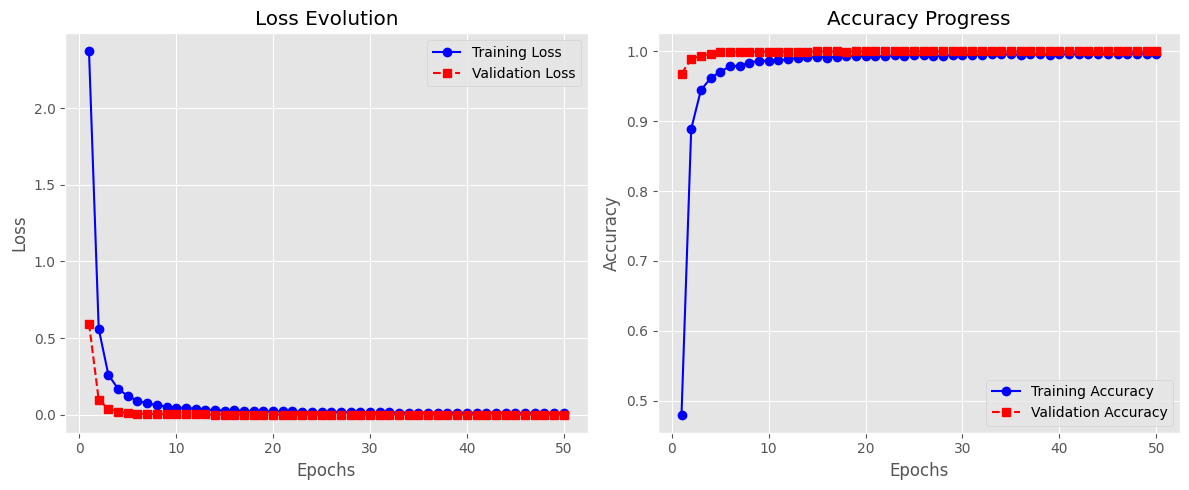

268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       240
           B       1.00      1.00      1.00       240
           C       1.00      1.00      1.00       289
           D       1.00      1.00      1.00       240
           E       1.00      1.00      1.00       240
           F       1.00      1.00      1.00       240
           G       1.00      1.00      1.00       240
           H       1.00      1.00      1.00       240
           I       1.00      1.00      1.00       276
           J       1.00      1.00      1.00       240
           K       1.00      1.00      1.00       240
           L       1.00      1.00      1.00       240
           M       1.00      1.00      1.00       240
           N       1.00      1.00      1.00       240
           O       1.00      1.00      1.00       286
           P       1.00      1.00      1.00       240
           Q    

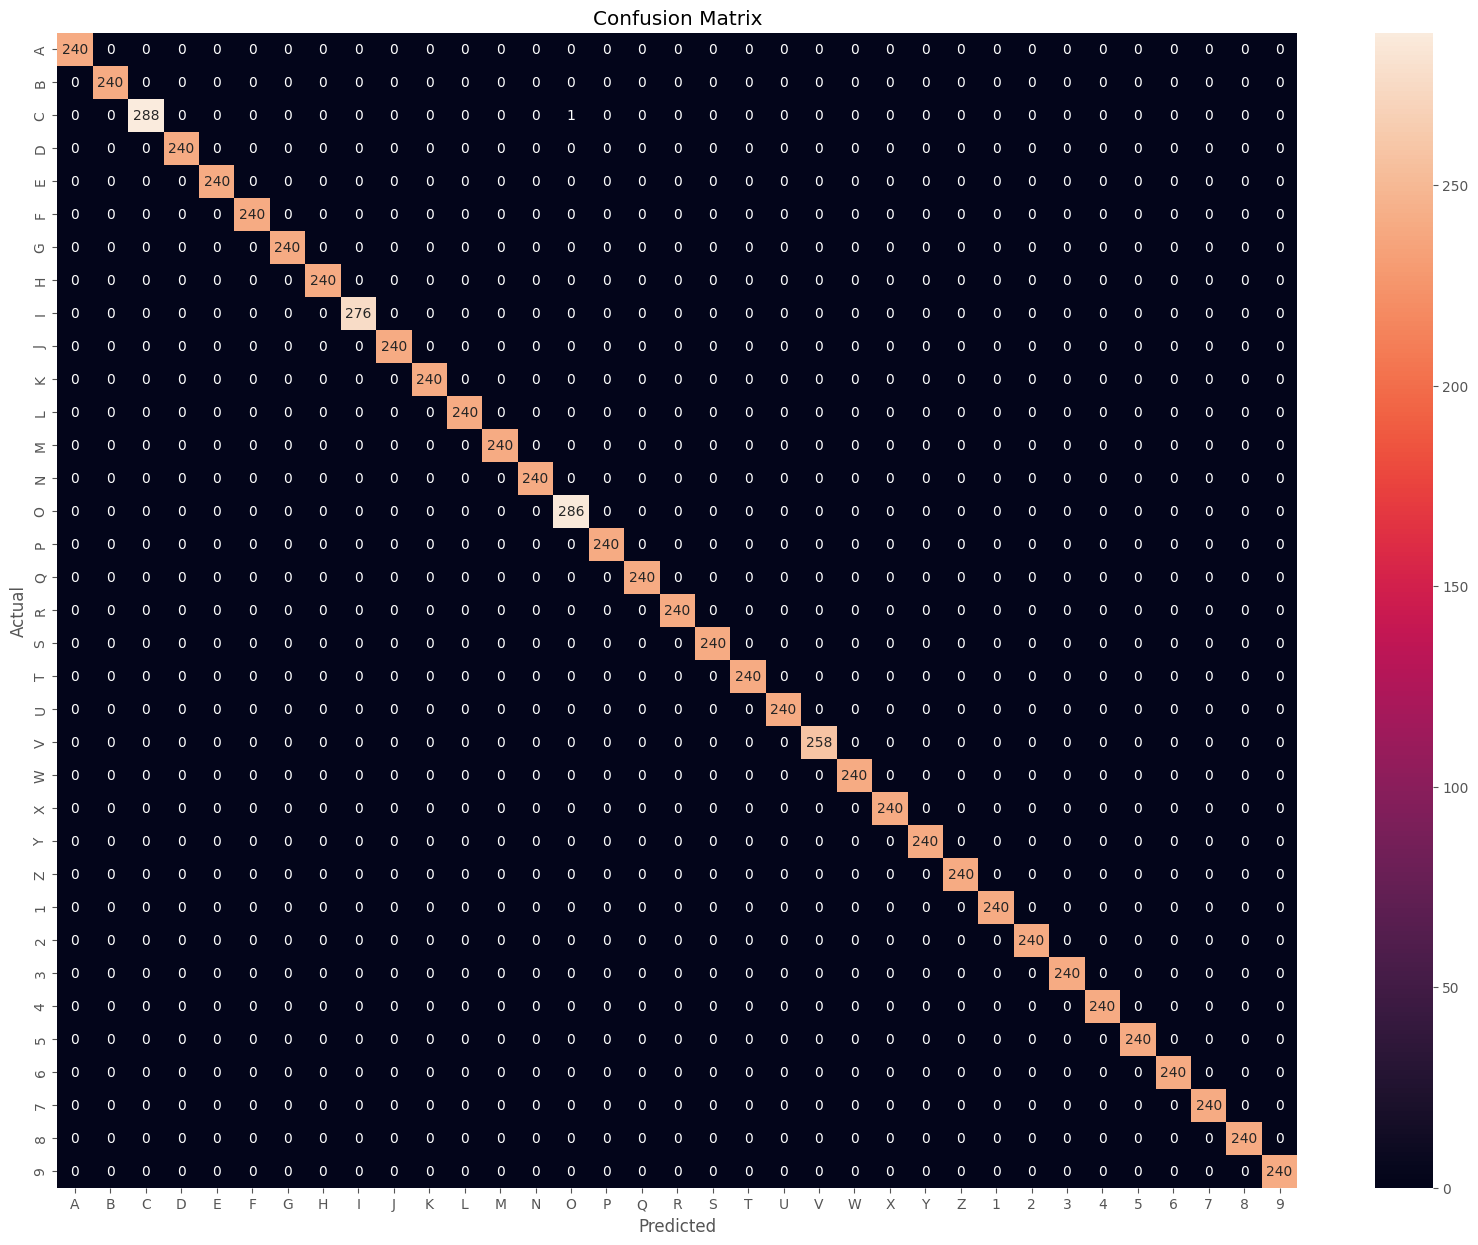

In [12]:
# Performance analysis
TrainingUtils.plot_training_history(history, EPOCHS)
TrainingUtils.generate_performance_report(
    model, x_test, y_test, loader.class_map
)

In [13]:
# Model persistence
model.save(MODEL_PATH)
print(f"\nModel saved to {MODEL_PATH}")


Model saved to isl_cnn_atn_v1.h5


# CNN Model


In [14]:
MODEL_PATH = 'isl_cnn_v1.h5'
EPOCHS = 50
LR = 1e-5

In [15]:
# Model setup
model = CNN_Model.build(input_shape=(*IMG_SIZE, 1))
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 128, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       8,388,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 35)                  │           8,995 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,490,531 (32.39 MB)

 Trainable params: 8,490,531 (32.39 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.10/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


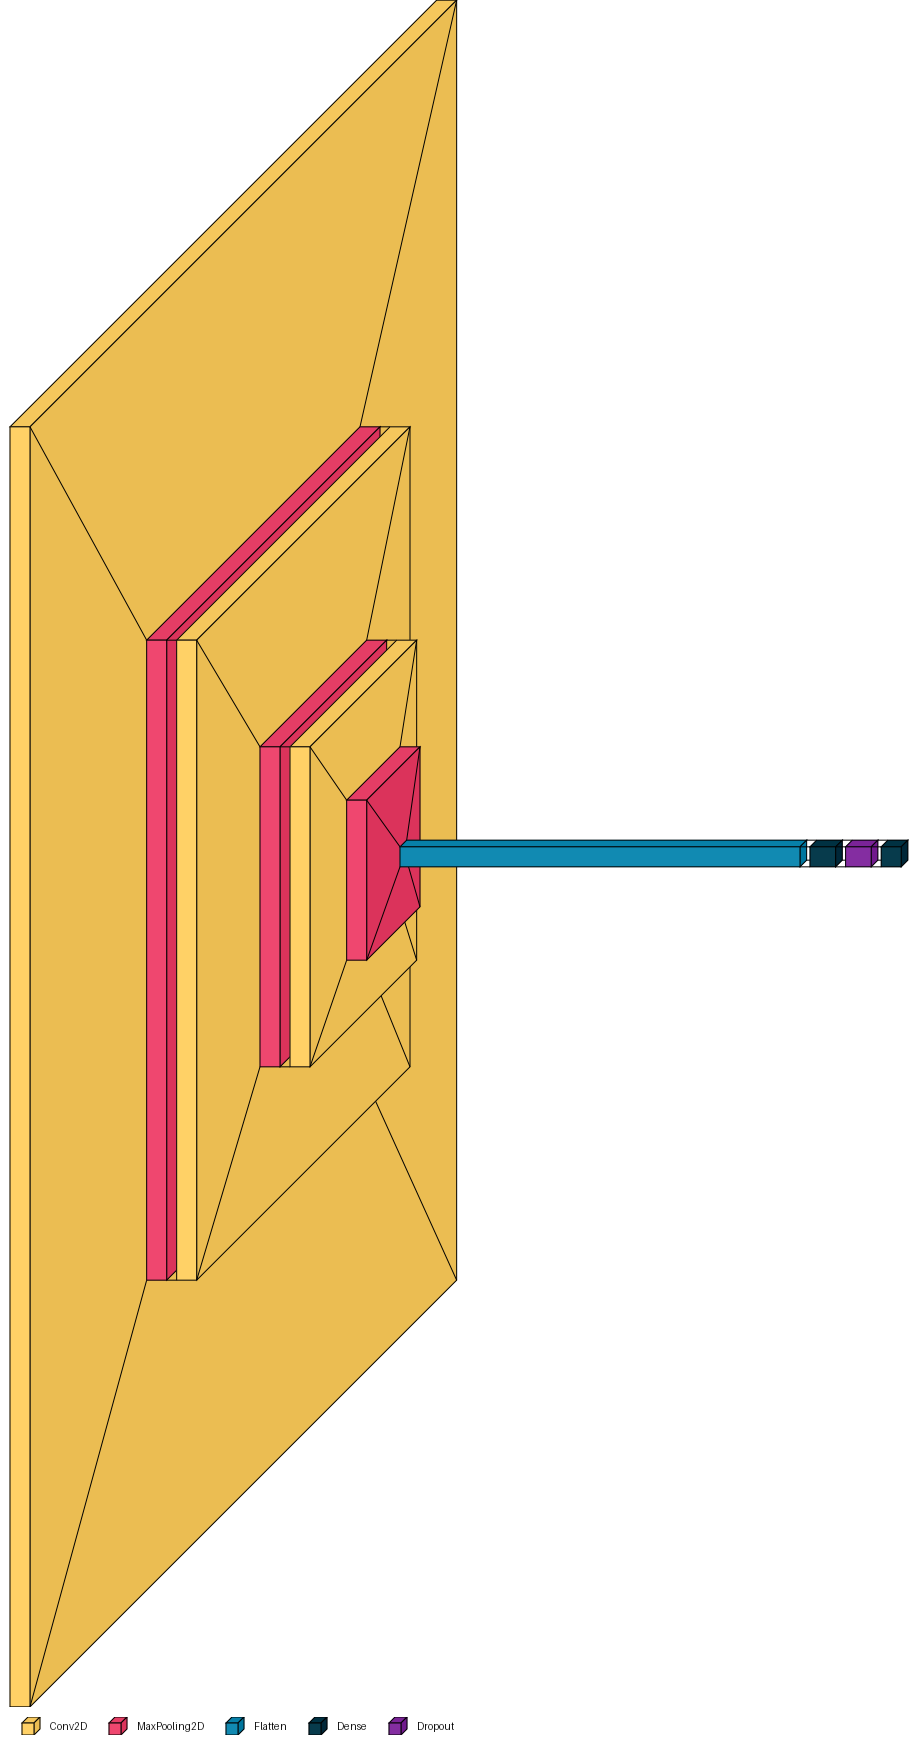

In [16]:
# Model visualization
print("Model Architecture:")
model.summary()
visualkeras.layered_view(model, legend=True, scale_xy=10)

In [17]:
# Training
print("\nStarting Training...")
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=32,
    verbose=1
)


Starting Training...
Epoch 1/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.3539 - loss: 2.7824 - val_accuracy: 0.9861 - val_loss: 0.1078
Epoch 2/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9726 - loss: 0.1591 - val_accuracy: 0.9958 - val_loss: 0.0207
Epoch 3/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9913 - loss: 0.0475 - val_accuracy: 0.9991 - val_loss: 0.0063
Epoch 4/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9963 - loss: 0.0210 - val_accuracy: 0.9997 - val_loss: 0.0027
Epoch 5/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9974 - loss: 0.0132 - val_accuracy: 0.9997 - val_loss: 0.0020
Epoch 6/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9988 - loss: 0.0073 - val_accuracy: 0.9997 - val_loss: 9.1393e-04
Epoch 7/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9993 - loss: 0.0053 - val_accuracy: 0.9999 - val_loss: 4.4683e-04
Epoch 8/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0

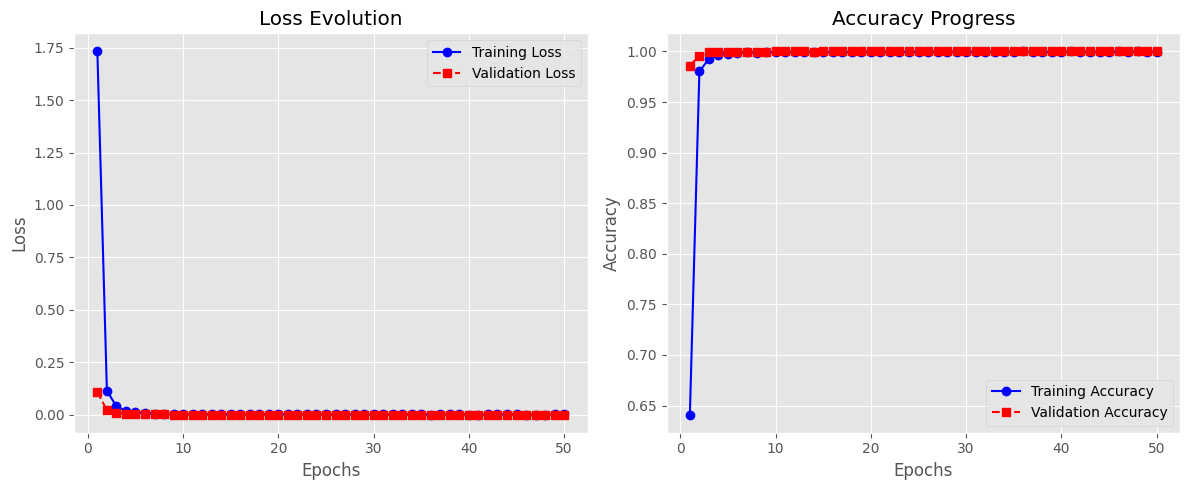

268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       240
           B       1.00      1.00      1.00       240
           C       1.00      1.00      1.00       289
           D       1.00      1.00      1.00       240
           E       1.00      1.00      1.00       240
           F       1.00      1.00      1.00       240
           G       1.00      1.00      1.00       240
           H       1.00      1.00      1.00       240
           I       1.00      1.00      1.00       276
           J       1.00      1.00      1.00       240
           K       1.00      1.00      1.00       240
           L       1.00      1.00      1.00       240
           M       1.00      1.00      1.00       240
           N       1.00      1.00      1.00       240
           O       1.00      1.00      1.00       286
           P       1.00      1.00      1.00       240
           Q    

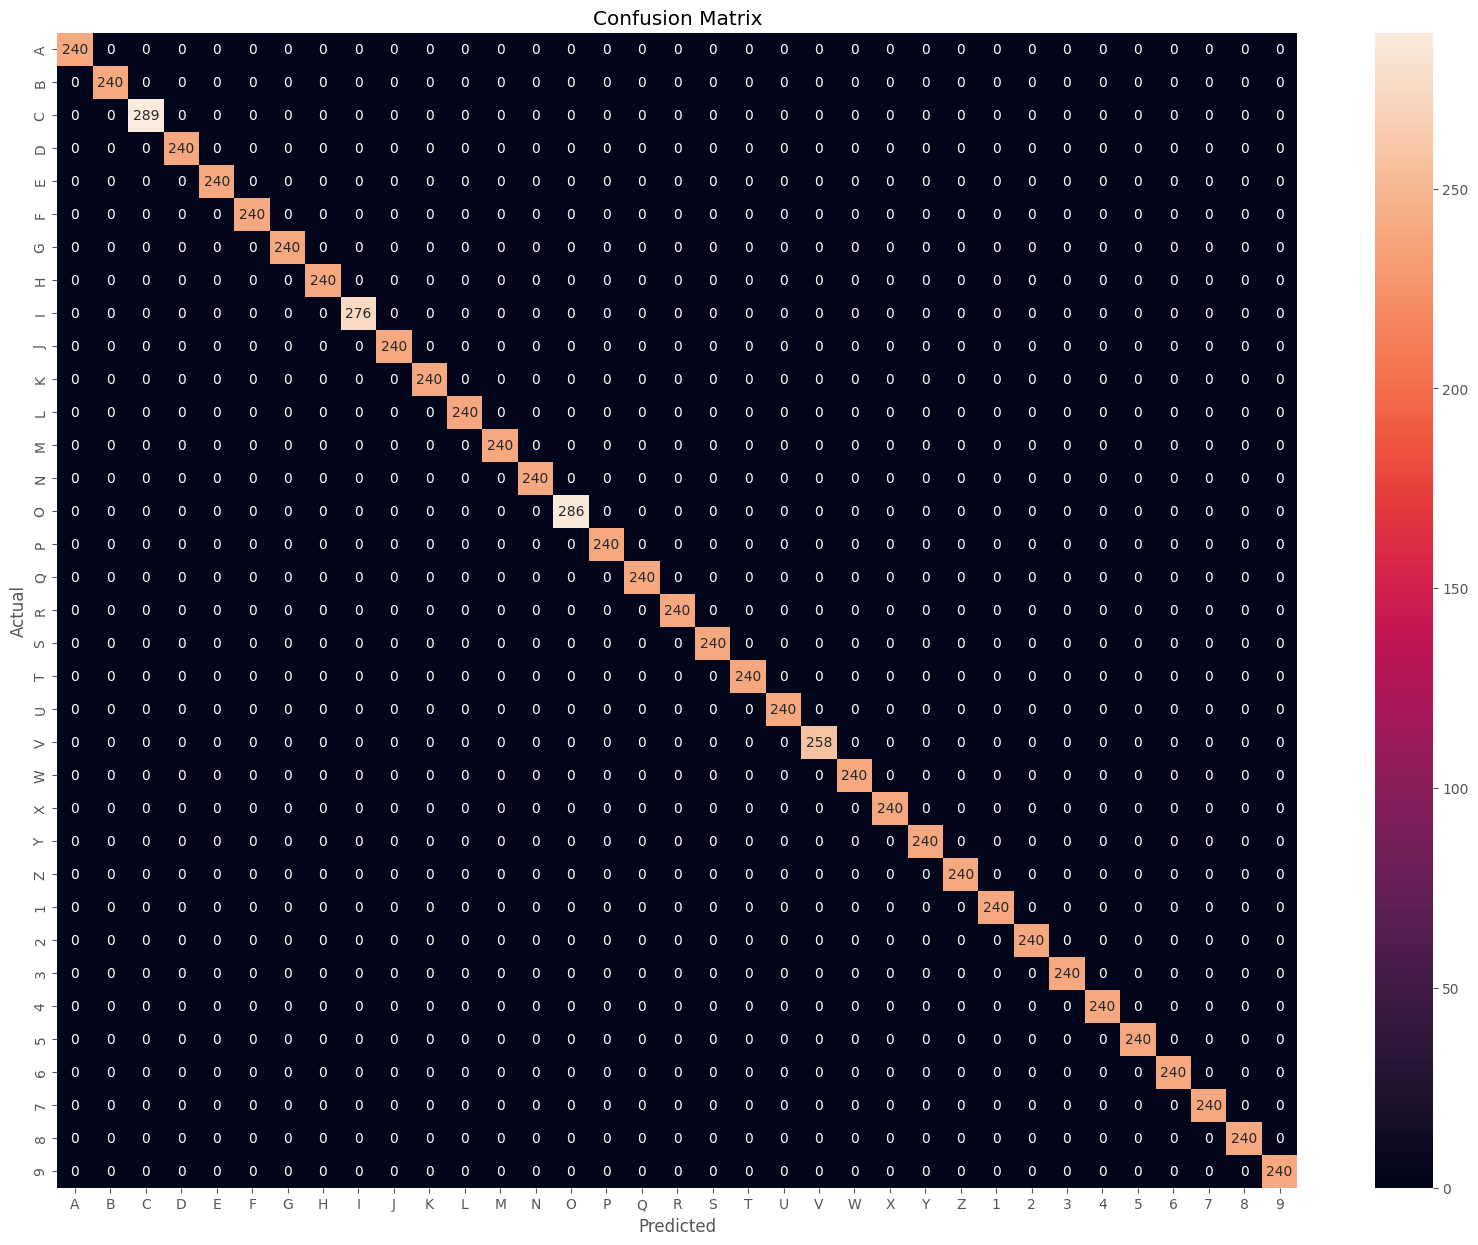

In [18]:
# Performance analysis
TrainingUtils.plot_training_history(history, EPOCHS)
TrainingUtils.generate_performance_report(
    model, x_test, y_test, loader.class_map
)

In [19]:
# Model persistence
model.save(MODEL_PATH)
print(f"\nModel saved to {MODEL_PATH}")


Model saved to isl_cnn_v1.h5


# LSTM Model

In [20]:
MODEL_PATH = 'isl_lstm_v1.h5'
EPOCHS = 50
LR = 1e-5

In [21]:
# Model setup
model = LSTM_Model.build(input_shape=(*IMG_SIZE, 1))
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 128, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_2 (Reshape)                  │ (None, 256, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 256, 128)            │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 35)                  │           4,515 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 286,499 (1.09 MB)

 Trainable params: 286,499 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.10/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


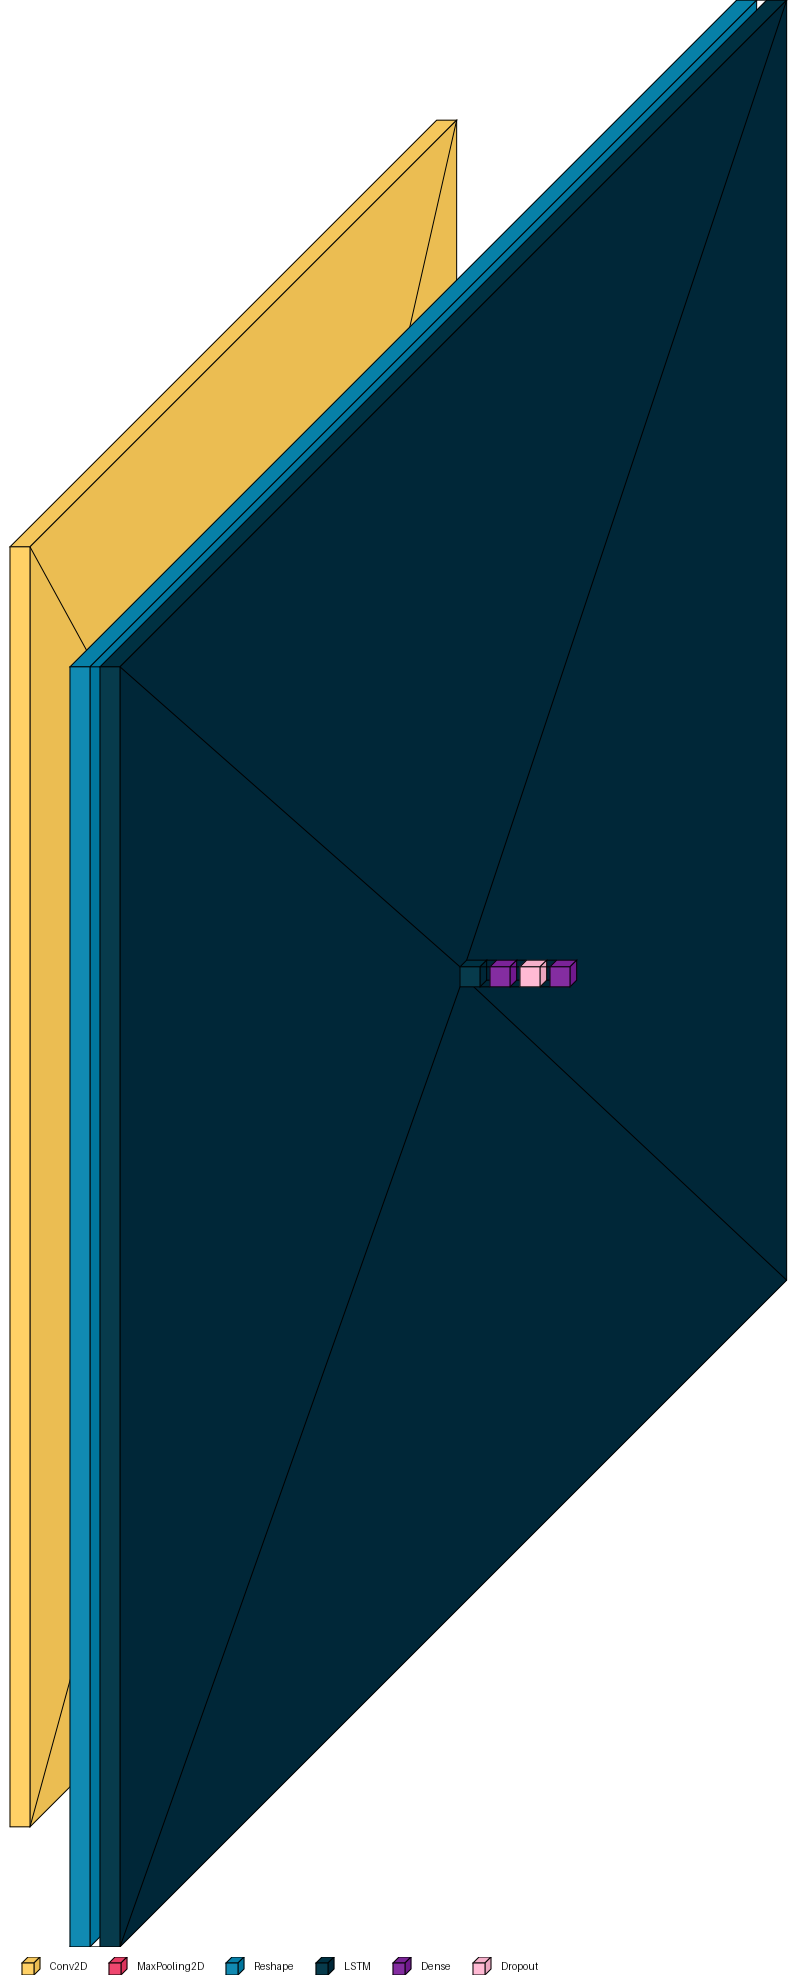

In [22]:
# Model visualization
print("Model Architecture:")
model.summary()
visualkeras.layered_view(model, legend=True, scale_xy=10)

In [23]:
# Training
print("\nStarting Training...")
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=32,
    verbose=1
)


Starting Training...
Epoch 1/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.0342 - loss: 3.5542 - val_accuracy: 0.0678 - val_loss: 3.5092
Epoch 2/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.0639 - loss: 3.4370 - val_accuracy: 0.1504 - val_loss: 3.1311
Epoch 3/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.3021 - loss: 2.4264 - val_accuracy: 0.5462 - val_loss: 1.9938
Epoch 6/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.3947 - loss: 2.1307 - val_accuracy: 0.6924 - val_loss: 1.7084
Epoch 7/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.4681 - loss: 1.8916 - val_accuracy: 0.7711 - val_loss: 1.4835
Epoch 8/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.5351 - loss: 1.6765 - val_accuracy: 0.7968 - val_loss: 1.2810
Epoch 9/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.5818 - loss: 1.5121 - val_accuracy: 0.8323 - val_loss: 1.1257
Epoch 10/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0

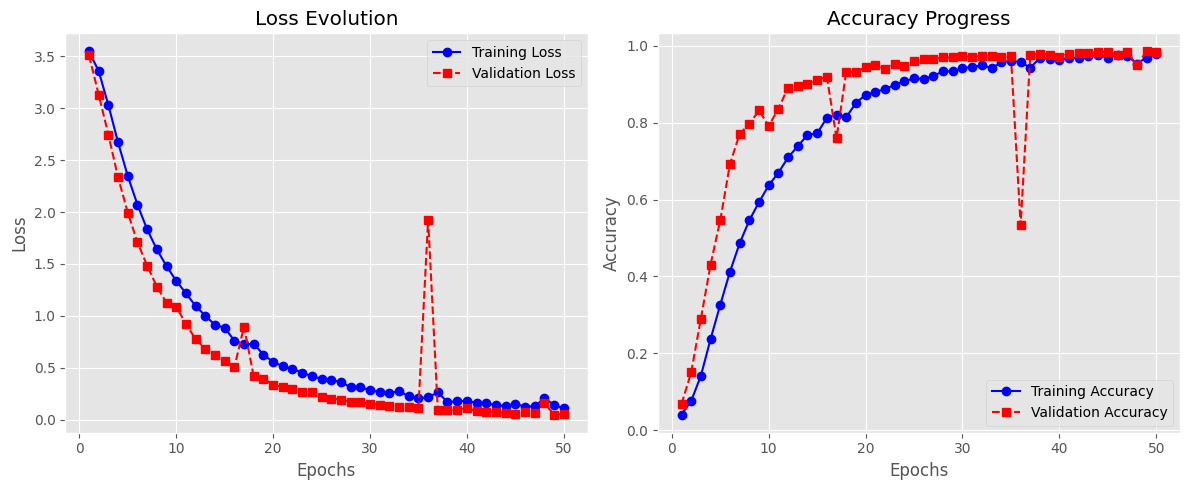

268/268 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step

Classification Report:
              precision    recall  f1-score   support

           A       0.98      0.93      0.96       240
           B       0.94      1.00      0.97       240
           C       0.85      1.00      0.92       289
           D       1.00      1.00      1.00       240
           E       0.99      1.00      1.00       240
           F       0.99      0.97      0.98       240
           G       1.00      1.00      1.00       240
           H       1.00      1.00      1.00       240
           I       0.97      0.84      0.90       276
           J       1.00      1.00      1.00       240
           K       1.00      1.00      1.00       240
           L       1.00      1.00      1.00       240
           M       1.00      1.00      1.00       240
           N       0.99      1.00      1.00       240
           O       0.94      0.97      0.95       286
           P       1.00      1.00      1.00       240
           Q   

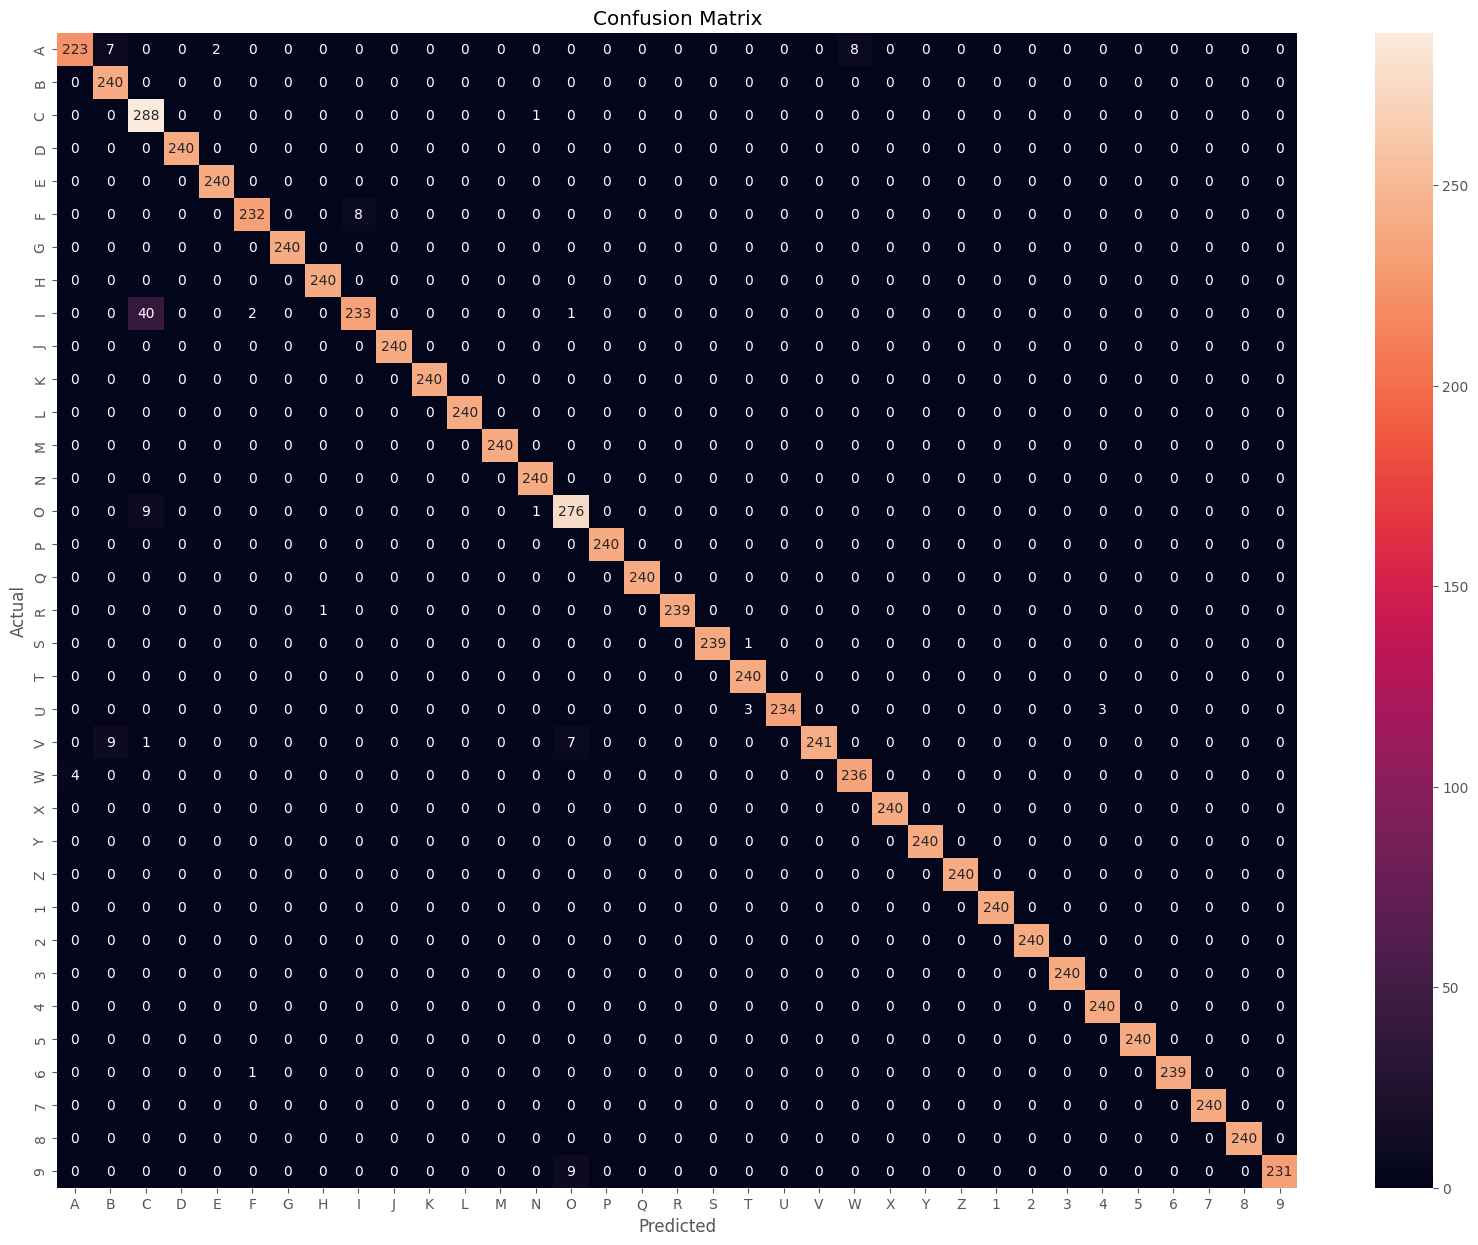

In [24]:
# Performance analysis
TrainingUtils.plot_training_history(history, EPOCHS)
TrainingUtils.generate_performance_report(
    model, x_test, y_test, loader.class_map
)

In [25]:
# Model persistence
model.save(MODEL_PATH)
print(f"\nModel saved to {MODEL_PATH}")


Model saved to isl_lstm_v1.h5
